# Baseline 訓練 — 單階段 9 類分類
每個 Cell 對應一個獨立步驟，可分開執行：
- **Cell 1**：環境設定（只需執行一次）
- **Cell 2**：實驗設定（換參數只改這裡，改完重跑 Cell 4+）
- **Cell 3**：載入資料（只需執行一次，換設定不需重跑）
- **Cell 4**：準備資料集與模型－這裡學習 loss 越小越好
- **Cell 5**：訓練（含即時圖表）
- **Cell 6**：測試集評估
- **Cell 7**：最終圖表
- **Cell 8**：儲存結果（選用）

In [ ]:
import sys
sys.path.insert(0, '..')
# Cell 1 — 環境設定（只需執行一次）
%matplotlib inline
import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tabulate import tabulate

from engine.trainer import print_metrics, print_per_class_f1, run_one_epoch, train_model
from engine.visualize import plot_cm, plot_history
from models.builder import build_model
from data.dataset import WaferDataset, extract_labeled_patterned_data, load_raw_data, make_dataloaders, split_df, undersample_none
from constant import LABEL_MAP
from utils import make_output_dir, save_results, set_seed

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"使用裝置：{device}")

In [ ]:
# Cell 2 — 實驗設定（換參數只改這裡，改完重跑 Cell 4+）
EXPERIMENT_NAME    = "base_loss"
IMAGE_SIZE         = (32,32)
BATCH_SIZE         = 32
EPOCHS             = 24
LR                 = 1e-3
RANDOM_SEED        = 42

set_seed(RANDOM_SEED)

In [8]:
# Cell 3 — 載入資料（只需執行一次，換設定不用重跑）
print("下載/讀取 WM-811K 資料集...")
df = load_raw_data()
df_with_label, _, _ = extract_labeled_patterned_data(df)
print(f"有標籤資料：{len(df_with_label)} 筆")

下載/讀取 WM-811K 資料集...
有標籤資料：172950 筆


In [9]:
# Cell 4 — 準備資料集與模型
train_df, val_df, test_df = split_df(
    df_with_label, stratify_col="failureType", random_seed=RANDOM_SEED,
)

num_classes = len(LABEL_MAP)
datasets = {
    "train": WaferDataset(train_df, image_size=IMAGE_SIZE),
    "val":   WaferDataset(val_df, image_size=IMAGE_SIZE),
    "test":  WaferDataset(test_df, image_size=IMAGE_SIZE),
}
dataloaders = make_dataloaders(datasets, BATCH_SIZE)

model = build_model(num_classes, device)
criterion = nn.CrossEntropyLoss()
params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = AdamW(params, lr=LR)

# loss 越小越好
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)
print(f"模型與資料集準備完成，類別數：{num_classes}")

模型與資料集準備完成，類別數：9


In [ ]:
# Cell 5 — 訓練
best_state, min_loss, best_cm, best_f1_per_class, history = train_model(
    model, device, criterion, optimizer, scheduler, dataloaders,
    num_classes=num_classes,
    epochs=EPOCHS,
    lr=LR,learning_depend_metric="loss"
)

===== Epoch 1/24 =====
+---------+--------+--------+--------+-------------+----------+
| Split   |   Loss |     F1 |    Acc |   Precision |   Recall |
+=========+========+========+========+=============+==========+
| Train   | 0.5454 | 0.2773 | 0.8764 |      0.369  |   0.2514 |
+---------+--------+--------+--------+-------------+----------+
| Val     | 0.3682 | 0.5113 | 0.9186 |      0.6509 |   0.4603 |
+---------+--------+--------+--------+-------------+----------+
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|   0.5514 |  0.4615 |     0.1655 |      0.8786 | 0.3243 |      0.6957 |   0.5646 |         0 | 0.9605 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+

===

In [15]:
# 取出 val_loss 最小那個 epoch 對應的 F1，供 save_results 使用
best_epoch = min(range(len(history)), key=lambda i: history[i]["val_loss"])
best_f1 = history[best_epoch]["val_f1"]
print(f"\n訓練完成，最佳驗證 F1：{best_f1:.4f}")


訓練完成，最佳驗證 F1：0.7299


In [16]:
# Cell 6 — 測試集評估
model.load_state_dict(best_state)
test_m = run_one_epoch(model, device, dataloaders["test"], criterion, num_classes=num_classes)
print("\n--- Test Results ---")
print(tabulate(
    [[f"{test_m['loss']:.4f}", f"{test_m['f1']:.4f}",
      f"{test_m['acc']:.4f}", f"{test_m['precision']:.4f}", f"{test_m['recall']:.4f}"]],
    headers=["Loss", "F1", "Acc", "Precision", "Recall"],
    tablefmt="grid",
))
print("\n--- Per-Class F1 ---")
print_per_class_f1(test_m["per_class_f1"])


--- Test Results ---
+--------+-------+--------+-------------+----------+
|   Loss |    F1 |    Acc |   Precision |   Recall |
+========+=======+========+=============+==========+
| 0.1361 | 0.733 | 0.9598 |      0.8092 |   0.7258 |
+--------+-------+--------+-------------+----------+

--- Per-Class F1 ---
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|   0.8752 |   0.759 |      0.732 |      0.9569 | 0.5761 |      0.6133 |   0.7182 |     0.384 | 0.9823 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+


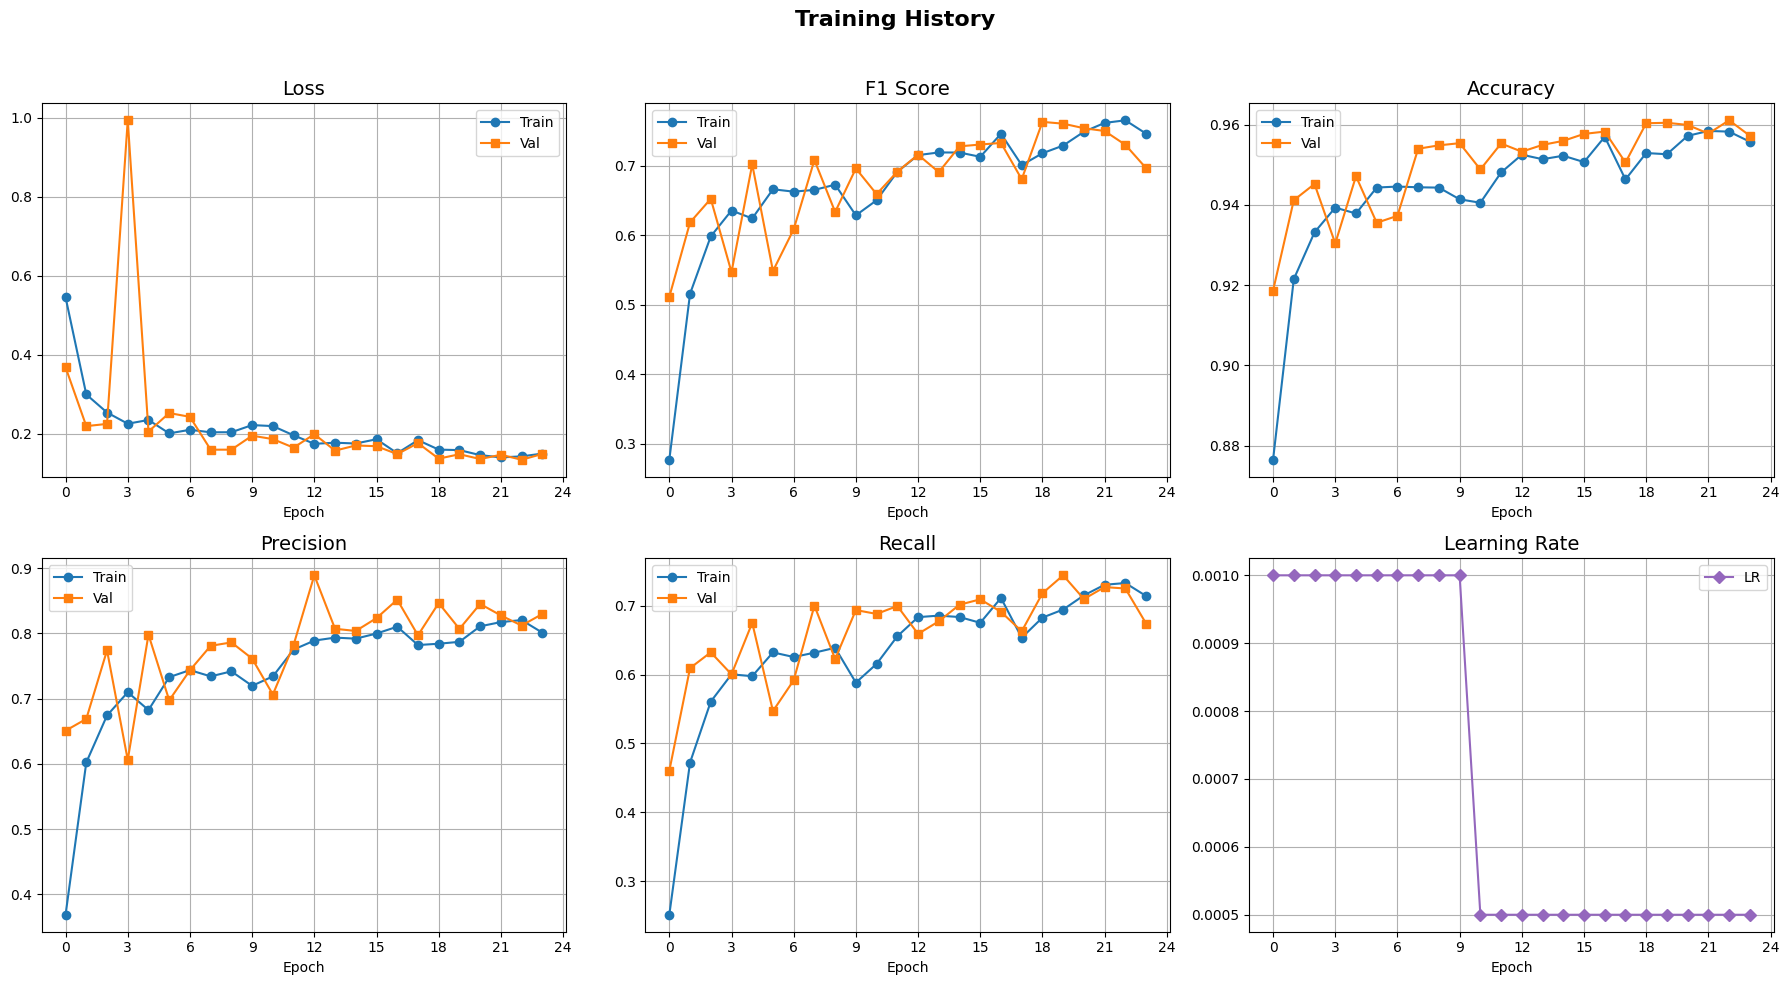

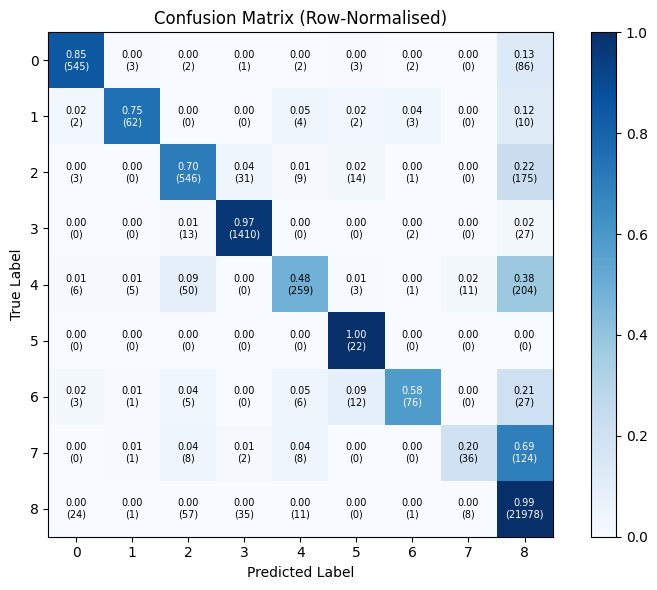


--- Best Val Per-Class F1 ---
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|   0.8883 |  0.7949 |     0.7479 |      0.9621 | 0.6181 |      0.5641 |   0.7037 |    0.3077 | 0.9823 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+


In [12]:
# Cell 7 — 最終圖表
plot_history(history, show=True)
plot_cm(best_cm, num_classes, show=True)
print("\n--- Best Val Per-Class F1 ---")
print_per_class_f1(best_f1_per_class)

In [ ]:
# Cell 8 — 儲存結果（選用）
out_dir = make_output_dir(EXPERIMENT_NAME)
save_results(
    out_dir, model, best_state, best_f1, test_m['f1'], test_m['cm'], test_m['per_class_f1'],
    history, num_classes, LABEL_MAP, IMAGE_SIZE,
)
print(f"結果已儲存至：{out_dir}")